# 04 Alex Implementation: Static Band + TWAP/VWAP Delta Hedging

This notebook is my own implementation of the `JPM_Optimal_Intraday_Delta_Hedging_v4`
proposal (`docs/JPM_Optimal_Intraday_Delta_Hedging__v2_.pdf` in this repo is the v2 draft;
this notebook follows the v4 static-band baseline). It reuses the team's Step 0 data
artifacts (`data/simulated/simulated_executed_trades.csv`, the synthetic ES option
trade-flow tape, and `data/processed/market_inputs_2026.csv`, the cleaned 5-minute
ES/SPX/SPY/BVOL/SOFR panel) but implements the hedging engine itself from scratch,
built directly off the proposal's equations rather than `02_baseline_strategies.ipynb`.

Two places where this implementation departs from `02_baseline_strategies.ipynb`,
both traced back to the proposal text:

1. **Unit convention (Eq. 11).** The proposal is explicit that the ES futures
   multiplier must *not* be applied when converting an option trade into its book-delta
   contribution, because an ES option's delta is already expressed in ES-futures-contract
   equivalents (both instruments share the same $50 multiplier, so it cancels). The
   shared baseline notebook multiplies by `ES_MULTIPLIER` a second time, which inflates
   every book-delta figure 50x. This notebook follows Eq. 11 literally: no multiplier at
   the delta-arrival stage.
2. **Continuous book-delta revaluation (Eq. 17-19).** The proposal defines
   `Delta_book(t_j)` as the sum of *all live option deltas repriced at the current bar's
   ES price*, not a running sum of deltas frozen at each trade's own execution price. The
   "Practical rule" box on p.8 says this explicitly: the model recomputes book delta from
   scratch at every 5-minute step. That is also the only way to reproduce the smooth,
   continuously-drifting Zero Hedge curve in the proposal's example figure (p.13) -- a
   frozen-delta cumulative sum only moves at trade arrivals and would look like a step
   function, not a drift. This notebook recomputes Black-76 deltas for the whole live book
   at every bar.

Everything else -- the static band with breach buffer and cooldown (Eq. 1-6), TWAP/VWAP
execution (Eq. 7-10), the execution-cost proxy (Eq. 12-16), the realized residual-delta
risk measure (Eq. 21-23), and the standardized cost-risk objective (Eq. 24-28) -- is
implemented directly from the proposal's equations.

In [1]:
from pathlib import Path
import itertools
import time

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
SIM_DIR = DATA_DIR / "simulated"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

EXECUTED_TRADES_PATH = SIM_DIR / "simulated_executed_trades.csv"
MARKET_INPUTS_PATH = PROCESSED_DIR / "market_inputs_2026.csv"

ES_MULTIPLIER = 50.0  # M_h -- dollars per ES futures index point
BAR_MINUTES = 5

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/xelaxela/Desktop/JPM INDUSTRY PROJECT


## 1. Load Executed Option Trade Flow and Market Inputs

`simulated_executed_trades.csv` is the synthetic ES-option execution tape (Section
"Option Trade-Flow Simulation" of the proposal): each row is one option print with side,
quantity, strike, option type, expiry, and the option's own bid/ask at execution.
`market_inputs_2026.csv` is the cleaned 5-minute ES/SPX/SPY panel with the flat 1M BVOL
and SOFR OIS inputs used for pricing, produced by `01_data_simulation.ipynb`.

In [2]:
def load_executed_trades(path: Path) -> pd.DataFrame:
    trades = pd.read_csv(path)
    trades["timestamp_utc"] = pd.to_datetime(trades["timestamp"], utc=True)
    trades["timestamp_et"] = trades["timestamp_utc"].dt.tz_convert("America/New_York").dt.tz_localize(None)
    trades["trade_date"] = trades["timestamp_et"].dt.normalize()
    trades["expiry_date"] = pd.to_datetime(trades["expiry_date"])
    trades["bar_time"] = trades["timestamp_et"].dt.floor(f"{BAR_MINUTES}min")
    trades["side"] = trades["side"].str.upper()
    trades["opt_type"] = trades["opt_type"].str.upper()
    return trades.sort_values("timestamp_et").reset_index(drop=True)


def load_market_inputs(path: Path) -> pd.DataFrame:
    market = pd.read_csv(path)
    market["timestamp_et"] = pd.to_datetime(market["timestamp_et"])
    market["trade_date"] = pd.to_datetime(market["trade_date"])
    return (
        market.sort_values("timestamp_et")
        .reset_index(drop=True)
        .rename(columns={"timestamp_et": "bar_time"})
    )


trades = load_executed_trades(EXECUTED_TRADES_PATH)
market = load_market_inputs(MARKET_INPUTS_PATH)

print(f"Executed option trades: {len(trades):,} across {trades['trade_date'].nunique()} trading days")
print(f"Market bars: {len(market):,} across {market['trade_date'].nunique()} trading days")
trades.head()

Executed option trades: 32,127 across 102 trading days
Market bars: 8,364 across 102 trading days


,trade_id,timestamp,sec_of_day,symbol,root,expiry_code,expiry_date,opt_type,strike,side,quantity,bid,ask,exec_price,timestamp_utc,timestamp_et,trade_date,bar_time
0,1,2026-01-02 14:42:39+00:00,52959,ESM6 P6100,ES,ESM6,2026-06-19,P,6100.0,SELL,2,95.75,96.00,95.345960,2026-01-02 14:42:39+00:00,2026-01-02 09:42:39,2026-01-02,2026-01-02 09:40:00
1,2,2026-01-02 14:48:58+00:00,53338,ESH6 C7325,ES,ESH6,2026-03-20,C,7325.0,SELL,15,19.75,20.00,20.209821,2026-01-02 14:48:58+00:00,2026-01-02 09:48:58,2026-01-02,2026-01-02 09:45:00
2,3,2026-01-02 14:52:13+00:00,53533,ESM6 P6800,ES,ESM6,2026-06-19,P,6800.0,BUY,15,225.75,226.25,220.270833,2026-01-02 14:52:13+00:00,2026-01-02 09:52:13,2026-01-02,2026-01-02 09:50:00
3,4,2026-01-02 14:53:41+00:00,53621,ESH6 C7000,ES,ESH6,2026-03-20,C,7000.0,BUY,1,104.50,104.75,112.590909,2026-01-02 14:53:41+00:00,2026-01-02 09:53:41,2026-01-02,2026-01-02 09:50:00
4,5,2026-01-02 14:53:57+00:00,53637,ESH6 P4500,ES,ESH6,2026-03-20,P,4500.0,BUY,5,4.45,4.50,4.632456,2026-01-02 14:53:57+00:00,2026-01-02 09:53:57,2026-01-02,2026-01-02 09:50:00


## 2. Delta Arrivals and the ES Unit Convention (Eq. 11)

For each option trade `i`, Eq. 11 defines its marginal book-delta contribution as
`Delta_new,i = s_i * n_i * delta_i` -- trade-direction sign times contract count times
option delta, **with no ES-futures multiplier**. `s_i` comes from side (`BUY` = +1,
`SELL` = -1), and `delta_i` will be evaluated with a Black-76 futures-option delta since
the underlying (`ES` options struck on ES futures) is a futures option, not an equity or
index option.

In [3]:
trades["side_sign"] = np.where(trades["side"].eq("BUY"), 1.0, -1.0)
trades["cp_sign"] = np.where(trades["opt_type"].eq("C"), 1, -1)
trades["dte_years"] = (trades["expiry_date"] - trades["trade_date"]).dt.days.clip(lower=1) / 365.0
trades["delta_weight"] = trades["side_sign"] * trades["quantity"]  # Eq. 11 pre-multiplier: s_i * n_i

incorrect_scale_example = (trades["delta_weight"] * ES_MULTIPLIER).abs().sum()
correct_scale_example = trades["delta_weight"].abs().sum()
print(
    f"Sum of |s_i * n_i| across the tape: {correct_scale_example:,.0f} contracts "
    f"(Eq. 11, correct unit convention)."
)
print(
    f"The same sum re-multiplied by M_h=50 as in 02_baseline_strategies.ipynb would read "
    f"{incorrect_scale_example:,.0f} -- a 50x unit-mismatch that this notebook avoids."
)
trades[["trade_id", "side", "quantity", "opt_type", "strike", "side_sign", "cp_sign", "dte_years", "delta_weight"]].head()

Sum of |s_i * n_i| across the tape: 661,367 contracts (Eq. 11, correct unit convention).
The same sum re-multiplied by M_h=50 as in 02_baseline_strategies.ipynb would read 33,068,350 -- a 50x unit-mismatch that this notebook avoids.


,trade_id,side,quantity,opt_type,strike,side_sign,cp_sign,dte_years,delta_weight
0,1,SELL,2,P,6100.0,-1.0,-1,0.460274,-2.0
1,2,SELL,15,C,7325.0,-1.0,1,0.210959,-15.0
2,3,BUY,15,P,6800.0,1.0,-1,0.460274,15.0
3,4,BUY,1,C,7000.0,1.0,1,0.210959,1.0
4,5,BUY,5,P,4500.0,1.0,-1,0.210959,5.0


## 3. Full-Book Delta Revaluation Engine (Eq. 17-19)

`Delta_book(t_j) = sum_i s_i * n_i * delta_i(t_j)` for every trade `i` executed at or
before `t_j`, with `delta_i(t_j)` a Black-76 delta repriced at bar `j`'s ES futures price,
that trading day's flat 1M BVOL, and that day's SOFR OIS rate. Because `Delta_book`
doesn't depend on the hedging strategy at all (it's just the option book's own repriced
exposure), it is computed once per trading day and reused across every strategy
configuration in the grid search below -- the expensive part of the backtest only needs
to run once.

In [4]:
def black76_delta(futures_price: np.ndarray, strike: np.ndarray, years: np.ndarray, vol: float, cp_sign: np.ndarray) -> np.ndarray:
    years = np.maximum(years, 1 / 365)
    vol = max(float(vol), 0.01)
    d1 = (np.log(futures_price / strike) + 0.5 * vol**2 * years) / (vol * np.sqrt(years))
    call_delta = norm.cdf(d1)
    return np.where(cp_sign == 1, call_delta, call_delta - 1.0)


def build_day_paths(trades: pd.DataFrame, market: pd.DataFrame) -> dict:
    day_paths = {}
    for trade_date, day_bars in market.groupby("trade_date"):
        day_bars = day_bars.sort_values("bar_time").reset_index(drop=True)
        day_trades = trades.loc[trades["trade_date"].eq(trade_date)].sort_values("bar_time").reset_index(drop=True)
        n_bars = len(day_bars)
        book_delta = np.zeros(n_bars)

        if len(day_trades) > 0:
            vol = float(day_bars["bvol_1m"].iloc[0])
            strike = day_trades["strike"].to_numpy()
            cp_sign = day_trades["cp_sign"].to_numpy()
            years = day_trades["dte_years"].to_numpy()
            weight = day_trades["delta_weight"].to_numpy()
            trade_bar_time = day_trades["bar_time"].to_numpy()
            bar_times = day_bars["bar_time"].to_numpy()
            live_count = np.searchsorted(trade_bar_time, bar_times, side="right")
            prices = day_bars["es1_price"].to_numpy(dtype=float)

            for j in range(n_bars):
                n_live = live_count[j]
                if n_live == 0:
                    continue
                deltas = black76_delta(prices[j], strike[:n_live], years[:n_live], vol, cp_sign[:n_live])
                book_delta[j] = float(np.dot(weight[:n_live], deltas))

        day_paths[trade_date] = dict(
            bar_time=day_bars["bar_time"].to_numpy(),
            es1_price=day_bars["es1_price"].to_numpy(dtype=float),
            es1_volume_5m=day_bars["es1_volume_5m"].to_numpy(dtype=float),
            es1_adv_20d=day_bars["es1_adv_20d"].to_numpy(dtype=float),
            book_delta=book_delta,
        )
    return day_paths


t0 = time.time()
day_paths = build_day_paths(trades, market)
print(f"Revalued the option book at every 5-minute bar for {len(day_paths)} trading days in {time.time() - t0:.2f}s")

Revalued the option book at every 5-minute bar for 102 trading days in 0.25s


### Why revaluation matters

The chart below contrasts, for one trading day, the frozen-delta cumulative sum (each
trade's delta fixed at its own execution price, as in `02_baseline_strategies.ipynb`)
against the continuously revalued book delta used in this notebook. The frozen version
only moves at trade arrivals and is flat in between; the revalued version keeps drifting
with the ES price even when no new option trades occur, because gamma keeps changing the
delta of the options already on the book. This is the behavior the proposal's example
intraday chart (p.13) shows for Zero Hedge.

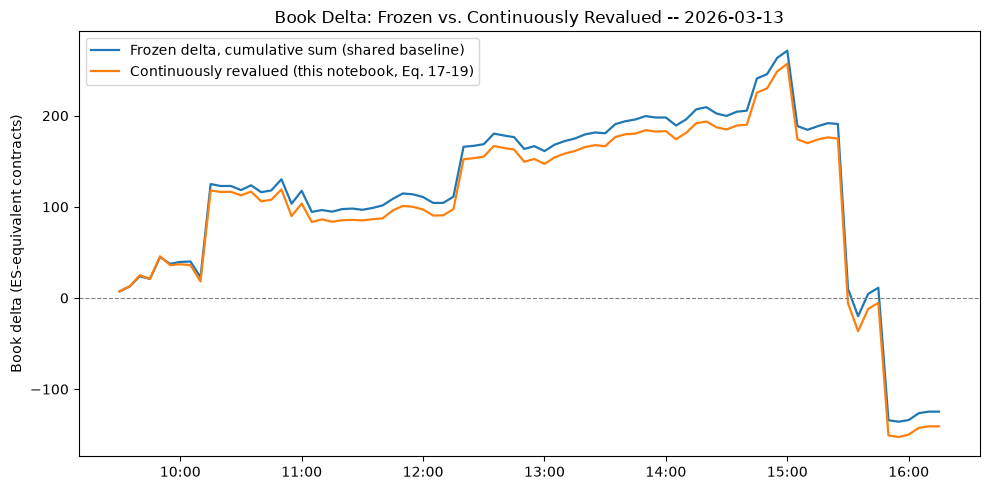

In [5]:
illustrative_date = max(day_paths, key=lambda d: len(trades.loc[trades["trade_date"].eq(d)]))
day_trades_illustrative = trades.loc[trades["trade_date"].eq(illustrative_date)].sort_values("bar_time")
day_bars_illustrative = market.loc[market["trade_date"].eq(illustrative_date)].sort_values("bar_time")

frozen_delta_by_bar = (
    day_trades_illustrative.groupby("bar_time")["delta_weight"].sum().reindex(day_bars_illustrative["bar_time"]).fillna(0.0)
)
# Frozen version uses each trade's own delta at its own execution price (no revaluation).
frozen_trade_delta = black76_delta(
    day_trades_illustrative["strike"].to_numpy() * 0
    + market.set_index("bar_time").loc[day_trades_illustrative["bar_time"], "es1_price"].to_numpy(),
    day_trades_illustrative["strike"].to_numpy(),
    day_trades_illustrative["dte_years"].to_numpy(),
    float(day_bars_illustrative["bvol_1m"].iloc[0]),
    day_trades_illustrative["cp_sign"].to_numpy(),
)
frozen_contrib = day_trades_illustrative["delta_weight"].to_numpy() * frozen_trade_delta
frozen_path = (
    pd.Series(frozen_contrib, index=day_trades_illustrative["bar_time"])
    .groupby(level=0).sum()
    .reindex(day_bars_illustrative["bar_time"], fill_value=0.0)
    .cumsum()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(day_bars_illustrative["bar_time"], frozen_path.to_numpy(), label="Frozen delta, cumulative sum (shared baseline)", linewidth=1.6)
ax.plot(day_bars_illustrative["bar_time"], day_paths[illustrative_date]["book_delta"], label="Continuously revalued (this notebook, Eq. 17-19)", linewidth=1.6)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title(f"Book Delta: Frozen vs. Continuously Revalued -- {illustrative_date.date()}")
ax.set_ylabel("Book delta (ES-equivalent contracts)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_FIGURE_DIR / "alex_revaluation_comparison.png", dpi=150)
plt.show()

## 4. Calibrating the No-Trade Band `H` to This Book's Scale

The proposal's example band grid (`H in {2,500, 5,000, 10,000, 20,000}`, p.3) is
illustrative, not prescriptive -- Eq. 6 explicitly treats `H` as "not assumed to be
optimal... selected through backtesting." Under the corrected Eq. 11 unit convention, the
realized book delta in this dataset is far smaller than those example values (the ES
option tape is bootstrapped from real per-trade sizes capped at 500 contracts). The
histogram below shows the distribution of each day's maximum absolute book delta; the
band grid used for the rest of this notebook is chosen to span that empirical range.

count    102.000000
mean     103.880153
std       82.028964
min       12.419093
25%       48.534853
50%       84.764604
75%      135.384619
max      608.816731
dtype: float64
Percentiles (50/75/90/95/99): [ 84.8 135.4 197.6 256.8 265.9]


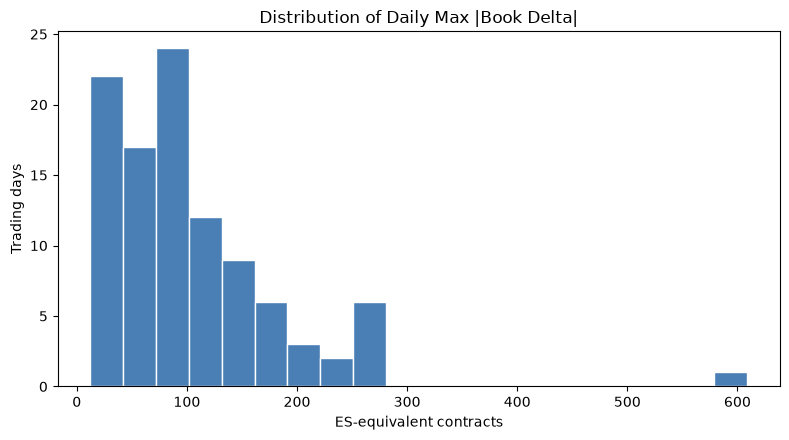


H grid (ES-equivalent contracts): [25, 50, 100, 200]


In [6]:
daily_max_abs_delta = pd.Series({d: np.max(np.abs(p["book_delta"])) for d, p in day_paths.items()})
print(daily_max_abs_delta.describe())
print("Percentiles (50/75/90/95/99):", np.percentile(daily_max_abs_delta, [50, 75, 90, 95, 99]).round(1))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(daily_max_abs_delta, bins=20, color="#4a7fb5", edgecolor="white")
ax.set_title("Distribution of Daily Max |Book Delta|")
ax.set_xlabel("ES-equivalent contracts")
ax.set_ylabel("Trading days")
fig.tight_layout()
fig.savefig(OUTPUT_FIGURE_DIR / "alex_book_delta_scale.png", dpi=150)
plt.show()

H_GRID = [25, 50, 100, 200]
EPS_GRID = [0.0, 0.05, 0.10]
COOLDOWN_GRID_MIN = [0, 15, 30]
HORIZON_GRID_MIN = [15, 30, 60]
METHOD_GRID = ["twap", "vwap"]
print(f"\nH grid (ES-equivalent contracts): {H_GRID}")

## 5. Trigger Rule, TWAP/VWAP Execution, and Execution Cost

- **Trigger with breach buffer and cooldown (Eq. 1-6 + refinement text):** hedge fires
  when `|Delta(t)| > H*(1+eps)`, unless a post-hedge cooldown of `T_cooldown` is active --
  the cooldown is overridden if the breach exceeds `2H`.
- **TWAP/VWAP execution (Eq. 7-10):** the parent order `Q_t = -Delta(t)` is split evenly
  over time (TWAP) or by expected ES futures volume share (VWAP) across the execution
  horizon `tau`.
- **Execution cost (Eq. 12-16):** `C_exec = spread cost + ADV-adjusted impact cost`. Real
  ES futures bid/ask quotes aren't available in this dataset (only OHLC/volume bars), so
  the half-spread is proxied by half of one ES tick (0.25 index points) -- a standard,
  heavily-traded front-month ES future almost always trades at the minimum tick spread.
  `alpha`, `beta` follow the proposal's own example sensitivity values and are swept in
  Section 10.

In [7]:
IMPACT_ALPHA = 0.05
IMPACT_BETA = 0.5
ES_HALF_SPREAD = 0.125  # half of 1 ES tick (0.25 index points)


def child_order_cost(qty: float, price: float, adv: float, half_spread: float = ES_HALF_SPREAD, alpha: float = IMPACT_ALPHA, beta: float = IMPACT_BETA):
    qty = abs(qty)
    if qty == 0.0:
        return 0.0, 0.0, 0.0
    adv = max(adv, 1.0)
    spread_cost = ES_MULTIPLIER * qty * half_spread
    participation = qty / adv
    impact_cost = ES_MULTIPLIER * alpha * price * qty * (participation ** beta)
    return spread_cost + impact_cost, spread_cost, impact_cost


def make_schedule(parent_qty: float, start_idx: int, n_bars: int, prices: np.ndarray, volumes: np.ndarray, horizon_min: float, method: str):
    n_child = max(int(round(horizon_min / BAR_MINUTES)), 1)
    idx = np.arange(start_idx, min(start_idx + n_child, n_bars))
    if len(idx) == 0:
        return idx, np.array([])
    if method == "twap":
        weights = np.full(len(idx), 1.0 / len(idx))
    elif method == "vwap":
        vol = np.clip(volumes[idx], 0, None)
        weights = vol / vol.sum() if vol.sum() > 0 else np.full(len(idx), 1.0 / len(idx))
    else:
        raise ValueError(f"Unknown execution method: {method}")
    return idx, parent_qty * weights


def simulate_day(day: dict, H, eps, cooldown_min, horizon_min, method, full_hedge=False, zero_hedge=False, return_path=False):
    """One trading day, one strategy configuration (Backtest Procedure, steps 1-9)."""
    n = len(day["bar_time"])
    prices, adv, vol5, book = day["es1_price"], day["es1_adv_20d"], day["es1_volume_5m"], day["book_delta"]

    hedge_cum = 0.0
    exec_cost = spread_cost = impact_cost = 0.0
    n_triggers = 0
    total_abs_hedge = 0.0
    sched_idx, sched_qty = np.array([], dtype=int), np.array([])
    cooldown_until = -1
    resid = np.zeros(n)

    for j in range(n):
        if full_hedge:
            target_hedge = -book[j]
            incremental = target_hedge - hedge_cum
            if incremental != 0.0:
                c, s, im = child_order_cost(incremental, prices[j], adv[j])
                exec_cost += c; spread_cost += s; impact_cost += im
                total_abs_hedge += abs(incremental)
                n_triggers += 1
            hedge_cum = target_hedge
            resid[j] = 0.0
            continue
        if zero_hedge:
            resid[j] = book[j]
            continue

        due = sched_idx == j
        if due.any():
            q = float(sched_qty[due].sum())
            if q != 0.0:
                c, s, im = child_order_cost(q, prices[j], adv[j])
                exec_cost += c; spread_cost += s; impact_cost += im
                total_abs_hedge += abs(q)
                hedge_cum += q

        delta_now = book[j] + hedge_cum
        resid[j] = delta_now

        in_cooldown = j < cooldown_until
        breach = abs(delta_now) > H * (1 + eps)
        override = abs(delta_now) > 2 * H
        if breach and (not in_cooldown or override):
            n_triggers += 1
            parent = -delta_now
            sched_idx, sched_qty = make_schedule(parent, j + 1, n, prices, vol5, horizon_min, method)
            sched_end = sched_idx[-1] if len(sched_idx) else j
            cooldown_until = sched_end + 1 + int(round(cooldown_min / BAR_MINUTES))

    close_qty = -resid[-1] if n > 0 else 0.0
    if not full_hedge and close_qty != 0.0:
        c, s, im = child_order_cost(close_qty, prices[-1], adv[-1])
        exec_cost += c; spread_cost += s; impact_cost += im
        total_abs_hedge += abs(close_qty)
        resid[-1] = 0.0
    if full_hedge:
        close_qty = 0.0

    price_diff = np.diff(prices)
    ell = ES_MULTIPLIER * resid[:-1] * price_diff  # Eq. 22
    result = dict(
        exec_cost=exec_cost, spread_cost=spread_cost, impact_cost=impact_cost,
        n_triggers=n_triggers, total_abs_hedge=total_abs_hedge,
        risk_sumsq=float(np.dot(ell, ell)), risk_count=len(ell),
        eod_delta_before_flatten=abs(close_qty),
    )
    if return_path:
        result["resid_path"] = resid
    return result

print("Engine defined: trigger rule + TWAP/VWAP execution + execution cost + realized-PnL risk.")

Engine defined: trigger rule + TWAP/VWAP execution + execution cost + realized-PnL risk.


## 6. Benchmarks: Zero Hedge and Full Hedge (Section 10)

- **Zero Hedge:** never rebalance intraday; only the forced end-of-day flattening trade.
  Lower bound on execution cost, upper bound on delta risk.
- **Full Hedge:** re-flatten `Delta(t)` to zero at every 5-minute bar (the finest
  granularity this backtest observes), offsetting both new trade arrivals and the
  gamma-driven drift of the existing book. Lower bound on delta risk (exactly zero), upper
  bound on execution cost.

In [8]:
def aggregate_over_days(day_paths: dict, **sim_kwargs) -> dict:
    agg = dict(exec_cost=0.0, spread_cost=0.0, impact_cost=0.0, n_triggers=0, total_abs_hedge=0.0, risk_sumsq=0.0, risk_count=0)
    for day in day_paths.values():
        r = simulate_day(day, **sim_kwargs)
        for k in agg:
            agg[k] += r[k]
    agg["risk_rms"] = (agg["risk_sumsq"] / agg["risk_count"]) ** 0.5 if agg["risk_count"] else 0.0
    return agg


zero_hedge_agg = aggregate_over_days(day_paths, H=None, eps=None, cooldown_min=None, horizon_min=None, method=None, zero_hedge=True)
full_hedge_agg = aggregate_over_days(day_paths, H=None, eps=None, cooldown_min=None, horizon_min=None, method=None, full_hedge=True)

benchmark_table = pd.DataFrame([
    {"strategy": "Zero Hedge", "execution_cost": zero_hedge_agg["exec_cost"], "delta_risk_rms": zero_hedge_agg["risk_rms"], "n_triggers": zero_hedge_agg["n_triggers"]},
    {"strategy": "Full Hedge", "execution_cost": full_hedge_agg["exec_cost"], "delta_risk_rms": full_hedge_agg["risk_rms"], "n_triggers": full_hedge_agg["n_triggers"]},
])
benchmark_table

,strategy,execution_cost,delta_risk_rms,n_triggers
0,Zero Hedge,1.473208e+06,24801.238131,0
1,Full Hedge,3.692884e+06,0.000000,8242


## 7. Grid Search Over theta = (H, eps, T_cooldown, e, tau) (Eq. 6, 10, 24, 31)

`H` follows the empirical grid from Section 4; `eps` in {0%, 5%, 10%}; `T_cooldown` in
{0, 15, 30} minutes; `tau` in {15, 30, 60} minutes (Eq. 10); `e` in {TWAP, VWAP}.

In [9]:
t0 = time.time()
grid_rows = []
for H, eps, cooldown_min, horizon_min, method in itertools.product(H_GRID, EPS_GRID, COOLDOWN_GRID_MIN, HORIZON_GRID_MIN, METHOD_GRID):
    agg = aggregate_over_days(day_paths, H=H, eps=eps, cooldown_min=cooldown_min, horizon_min=horizon_min, method=method)
    grid_rows.append(dict(
        H=H, eps=eps, cooldown_min=cooldown_min, horizon_min=horizon_min, method=method,
        execution_cost=agg["exec_cost"], spread_cost=agg["spread_cost"], impact_cost=agg["impact_cost"],
        delta_risk_rms=agg["risk_rms"], n_triggers=agg["n_triggers"], total_abs_hedge=agg["total_abs_hedge"],
    ))
grid_df = pd.DataFrame(grid_rows)
print(f"Grid search over {len(grid_df)} configurations in {time.time() - t0:.2f}s")
grid_df.to_csv(OUTPUT_TABLE_DIR / "alex_grid_results.csv", index=False)
grid_df.sort_values("execution_cost").head(10)

Grid search over 216 configurations in 2.31s


,H,eps,cooldown_min,horizon_min,method,execution_cost,spread_cost,impact_cost,delta_risk_rms,n_triggers,total_abs_hedge
34,25,0.05,30,60,twap,889970.704202,112845.301702,777125.402500,8732.448017,816,18055.248272
40,25,0.10,0,60,twap,898677.791502,114980.602592,783697.188910,8619.633850,833,18396.896415
46,25,0.10,15,60,twap,898866.809379,114022.690264,784844.119115,8661.856919,824,18243.630442
52,25,0.10,30,60,twap,899032.195685,112548.383972,786483.811713,8730.150442,819,18007.741436
28,25,0.05,15,60,twap,899654.825701,115237.759916,784417.065785,8674.956552,829,18438.041587
16,25,0.00,30,60,twap,903311.186607,115858.456981,787452.729626,8734.314694,843,18537.353117
22,25,0.05,0,60,twap,903583.903209,116922.090964,786661.812245,8654.279459,842,18707.534554
10,25,0.00,15,60,twap,908656.274212,117966.608381,790689.665831,8676.728403,849,18874.657341
4,25,0.00,0,60,twap,912823.192888,120053.480142,792769.712745,8637.817902,864,19208.556823
106,50,0.10,30,60,twap,916478.872944,92538.359676,823940.513269,9802.657877,258,14806.137548


## 8. Standardized Objective and Optimal Configuration (Eq. 24-28)

`C_exec_tilde(theta) = C_exec(theta) / C_exec(Full Hedge)`,
`C_risk_tilde(theta) = C_risk(theta) / C_risk(Zero Hedge)`,
`L_std(theta) = C_exec_tilde(theta) + lambda_risk * C_risk_tilde(theta)`.
Base case `lambda_risk = 1.0` (both terms are already O(1) after normalization, unlike a
raw-unit weight that has to absorb a cost/risk scale mismatch of several orders of
magnitude).

In [10]:
LAMBDA_RISK_BASE = 1.0

grid_df["cost_norm"] = grid_df["execution_cost"] / full_hedge_agg["exec_cost"]
grid_df["risk_norm"] = grid_df["delta_risk_rms"] / zero_hedge_agg["risk_rms"]
grid_df["L_std"] = grid_df["cost_norm"] + LAMBDA_RISK_BASE * grid_df["risk_norm"]

theta_star = grid_df.sort_values("L_std").iloc[0]
print("theta* =", dict(H=theta_star["H"], eps=theta_star["eps"], cooldown_min=theta_star["cooldown_min"], horizon_min=theta_star["horizon_min"], method=theta_star["method"]))

summary_table = pd.DataFrame([
    {"strategy": "Zero Hedge", "execution_cost": zero_hedge_agg["exec_cost"], "delta_risk_rms": zero_hedge_agg["risk_rms"],
     "cost_norm": zero_hedge_agg["exec_cost"] / full_hedge_agg["exec_cost"], "risk_norm": 1.0},
    {"strategy": "Full Hedge", "execution_cost": full_hedge_agg["exec_cost"], "delta_risk_rms": full_hedge_agg["risk_rms"],
     "cost_norm": 1.0, "risk_norm": full_hedge_agg["risk_rms"] / zero_hedge_agg["risk_rms"]},
    {"strategy": f"Static Band theta* (H={theta_star['H']:.0f}, eps={theta_star['eps']:.0%}, cooldown={theta_star['cooldown_min']:.0f}m, {theta_star['method'].upper()}, {theta_star['horizon_min']:.0f}m)",
     "execution_cost": theta_star["execution_cost"], "delta_risk_rms": theta_star["delta_risk_rms"],
     "cost_norm": theta_star["cost_norm"], "risk_norm": theta_star["risk_norm"]},
])
summary_table["L_std"] = summary_table["cost_norm"] + LAMBDA_RISK_BASE * summary_table["risk_norm"]
summary_table

theta* = {'H': np.int64(25), 'eps': np.float64(0.1), 'cooldown_min': np.int64(0), 'horizon_min': np.int64(60), 'method': 'twap'}


,strategy,execution_cost,delta_risk_rms,cost_norm,risk_norm,L_std
0,Zero Hedge,1.473208e+06,24801.238131,0.398932,1.000000,1.398932
1,Full Hedge,3.692884e+06,0.000000,1.000000,0.000000,1.000000
2,"Static Band theta* (H=25, eps=10%, cooldown=0m...",8.986778e+05,8619.633850,0.243354,0.347549,0.590902


## 9. Efficient Frontier (Execution Cost vs. Delta Risk, Standardized)

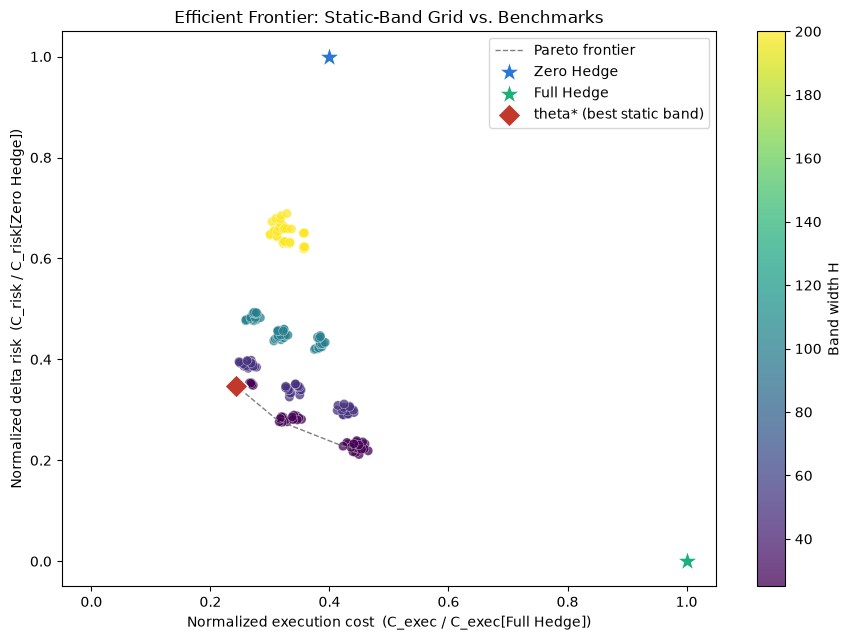

Pareto-efficient configurations: 9 of 216


In [11]:
def pareto_frontier(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    ordered = df.sort_values([x_col, y_col]).reset_index(drop=True)
    keep, best_y = [], np.inf
    for i, row in ordered.iterrows():
        if row[y_col] < best_y:
            keep.append(i)
            best_y = row[y_col]
    return ordered.loc[keep]


frontier = pareto_frontier(grid_df, "cost_norm", "risk_norm")

fig, ax = plt.subplots(figsize=(9, 6.5))
sc = ax.scatter(grid_df["cost_norm"], grid_df["risk_norm"], c=grid_df["H"], cmap="viridis", s=45, alpha=0.75, edgecolor="white", linewidth=0.3)
ax.plot(frontier["cost_norm"], frontier["risk_norm"], color="grey", linestyle="--", linewidth=1, zorder=2, label="Pareto frontier")
ax.scatter([0.0], [0.0], marker="*", s=0)  # keep origin in view
ax.scatter([summary_table.loc[0, "cost_norm"]], [summary_table.loc[0, "risk_norm"]], marker="*", s=260, color="#2a78d6", edgecolor="white", label="Zero Hedge", zorder=4)
ax.scatter([summary_table.loc[1, "cost_norm"]], [summary_table.loc[1, "risk_norm"]], marker="*", s=260, color="#1baf7a", edgecolor="white", label="Full Hedge", zorder=4)
ax.scatter([theta_star["cost_norm"]], [theta_star["risk_norm"]], marker="D", s=140, color="#c0392b", edgecolor="white", label="theta* (best static band)", zorder=5)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Band width H")
ax.set_xlabel("Normalized execution cost  (C_exec / C_exec[Full Hedge])")
ax.set_ylabel("Normalized delta risk  (C_risk / C_risk[Zero Hedge])")
ax.set_title("Efficient Frontier: Static-Band Grid vs. Benchmarks")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_FIGURE_DIR / "alex_efficient_frontier.png", dpi=150)
plt.show()

print(f"Pareto-efficient configurations: {len(frontier)} of {len(grid_df)}")

## 10. Sensitivity Analysis

Mirrors the proposal's parameter table (p.10-11): grid search for `H`, `T_cooldown`,
`tau`; direct comparison for `e`; sensitivity sweeps for `alpha`, `beta` (held via `beta`
fixed, same reasoning as the shared baseline: rescaling the impact exponent needs
per-order participation rates that aren't retained at the aggregate grain), the spread
assumption, and the risk-penalty weight `lambda_risk`.

In [12]:
band_sensitivity = grid_df.groupby("H").agg(execution_cost=("execution_cost", "mean"), delta_risk_rms=("delta_risk_rms", "mean"), n_triggers=("n_triggers", "mean")).reset_index()
print("Band-width sensitivity (averaged over eps, cooldown, horizon, method):")
print(band_sensitivity.to_string(index=False))

binding_H = int(band_sensitivity.loc[band_sensitivity["n_triggers"].gt(0), "H"].min())
horizon_sensitivity = (
    grid_df.loc[grid_df["H"].eq(binding_H)]
    .groupby("horizon_min")
    .agg(execution_cost=("execution_cost", "mean"), delta_risk_rms=("delta_risk_rms", "mean"))
    .reset_index()
)
print(f"\nExecution-horizon sensitivity (H={binding_H}):")
print(horizon_sensitivity.to_string(index=False))

method_sensitivity = grid_df.groupby("method").agg(execution_cost=("execution_cost", "mean"), delta_risk_rms=("delta_risk_rms", "mean")).reset_index()
print("\nTWAP vs. VWAP (averaged over the rest of the grid):")
print(method_sensitivity.to_string(index=False))

Band-width sensitivity (averaged over eps, cooldown, horizon, method):
  H  execution_cost  delta_risk_rms  n_triggers
 25    1.273363e+06     7112.565514  655.462963
 50    1.268304e+06     8521.278048  239.870370
100    1.198992e+06    11285.434794   67.277778
200    1.227363e+06    15984.433858   12.555556

Execution-horizon sensitivity (H=25):
 horizon_min  execution_cost  delta_risk_rms
          15    1.644556e+06     5645.459900
          30    1.226945e+06     6999.747163
          60    9.485870e+05     8692.489479

TWAP vs. VWAP (averaged over the rest of the grid):
method  execution_cost  delta_risk_rms
  twap    1.219791e+06    10701.614096
  vwap    1.264220e+06    10750.242011


In [13]:
SPREAD_MULTIPLIERS = [0.5, 1.0, 2.0, 4.0]
IMPACT_MULTIPLIERS = [0.5, 1.0, 2.0, 4.0]


def rescale_costs(df: pd.DataFrame, spread_mult: float = 1.0, impact_mult: float = 1.0) -> pd.DataFrame:
    out = df.copy()
    out["execution_cost"] = out["spread_cost"] * spread_mult + out["impact_cost"] * impact_mult
    return out


def best_row(rescaled: pd.DataFrame, zero_cost: float, full_cost_scaled: float) -> pd.Series:
    r = rescaled.copy()
    r["cost_norm"] = r["execution_cost"] / full_cost_scaled
    return r.sort_values("cost_norm").iloc[0]


full_hedge_spread = full_hedge_agg["spread_cost"]
full_hedge_impact = full_hedge_agg["impact_cost"]

spread_rows = []
for mult in SPREAD_MULTIPLIERS:
    rescaled = rescale_costs(grid_df, spread_mult=mult, impact_mult=1.0)
    full_cost_scaled = full_hedge_spread * mult + full_hedge_impact
    best = best_row(rescaled, zero_hedge_agg["exec_cost"], full_cost_scaled)
    spread_rows.append({"spread_multiplier": mult, "best_H": best["H"], "best_method": best["method"], "best_execution_cost": best["execution_cost"]})
spread_sensitivity = pd.DataFrame(spread_rows)

impact_rows = []
for mult in IMPACT_MULTIPLIERS:
    rescaled = rescale_costs(grid_df, spread_mult=1.0, impact_mult=mult)
    full_cost_scaled = full_hedge_spread + full_hedge_impact * mult
    best = best_row(rescaled, zero_hedge_agg["exec_cost"], full_cost_scaled)
    impact_rows.append({"impact_multiplier": mult, "implied_alpha": IMPACT_ALPHA * mult, "best_H": best["H"], "best_method": best["method"], "best_execution_cost": best["execution_cost"]})
impact_sensitivity = pd.DataFrame(impact_rows)

print("Spread-assumption sensitivity (impact held at 1.0x):")
print(spread_sensitivity.to_string(index=False))
print("\nImpact-alpha sensitivity (spread held at 1.0x):")
print(impact_sensitivity.to_string(index=False))

Spread-assumption sensitivity (impact held at 1.0x):
 spread_multiplier  best_H best_method  best_execution_cost
               0.5      25        twap         8.335481e+05
               1.0      25        twap         8.899707e+05
               2.0      25        twap         1.002816e+06
               4.0     100        twap         1.170093e+06

Impact-alpha sensitivity (spread held at 1.0x):
 impact_multiplier  implied_alpha  best_H best_method  best_execution_cost
               0.5          0.025      25        twap         5.014080e+05
               1.0          0.050      25        twap         8.899707e+05
               2.0          0.100      25        twap         1.667096e+06
               4.0          0.200      25        twap         3.221347e+06


In [14]:
LAMBDA_GRID = [0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]
lambda_rows = []
for lam in LAMBDA_GRID:
    candidate = grid_df.copy()
    candidate["L_std"] = candidate["cost_norm"] + lam * candidate["risk_norm"]
    winner = candidate.sort_values("L_std").iloc[0]
    full_hedge_L = 1.0 + lam * (full_hedge_agg["risk_rms"] / zero_hedge_agg["risk_rms"])
    lambda_rows.append(dict(lambda_risk=lam, best_H=winner["H"], best_eps=winner["eps"], best_method=winner["method"],
                             best_horizon_min=winner["horizon_min"], static_band_L=winner["L_std"], full_hedge_L=full_hedge_L))
lambda_sensitivity = pd.DataFrame(lambda_rows)
print("Risk-penalty-weight sensitivity:")
print(lambda_sensitivity.to_string(index=False))
crossover = lambda_sensitivity.loc[lambda_sensitivity["static_band_L"] > lambda_sensitivity["full_hedge_L"]]
if len(crossover):
    print(f"\nFull Hedge overtakes the best static band once lambda_risk >= {crossover['lambda_risk'].iloc[0]:g}")
else:
    print(f"\nFull Hedge does not overtake the best static band anywhere in the tested grid (up to lambda_risk={LAMBDA_GRID[-1]:g}).")

Risk-penalty-weight sensitivity:
 lambda_risk  best_H  best_eps best_method  best_horizon_min  static_band_L  full_hedge_L
        0.10      25      0.05        twap                60       0.276206           1.0
        0.25      25      0.05        twap                60       0.329020           1.0
        0.50      25      0.05        twap                60       0.417045           1.0
        1.00      25      0.10        twap                60       0.590902           1.0
        2.00      25      0.10        twap                30       0.868804           1.0
        5.00      25      0.00        twap                15       1.507683           1.0
       10.00      25      0.00        twap                15       2.565641           1.0

Full Hedge overtakes the best static band once lambda_risk >= 5


## 11. Example Intraday Walk-Through

The busiest trading day (by option-trade count) under theta*, contrasting Zero Hedge,
Full Hedge, and the selected static-band strategy -- book delta path and the resulting
cumulative delta P&L, in the style of the proposal's example figures (p.13-14).

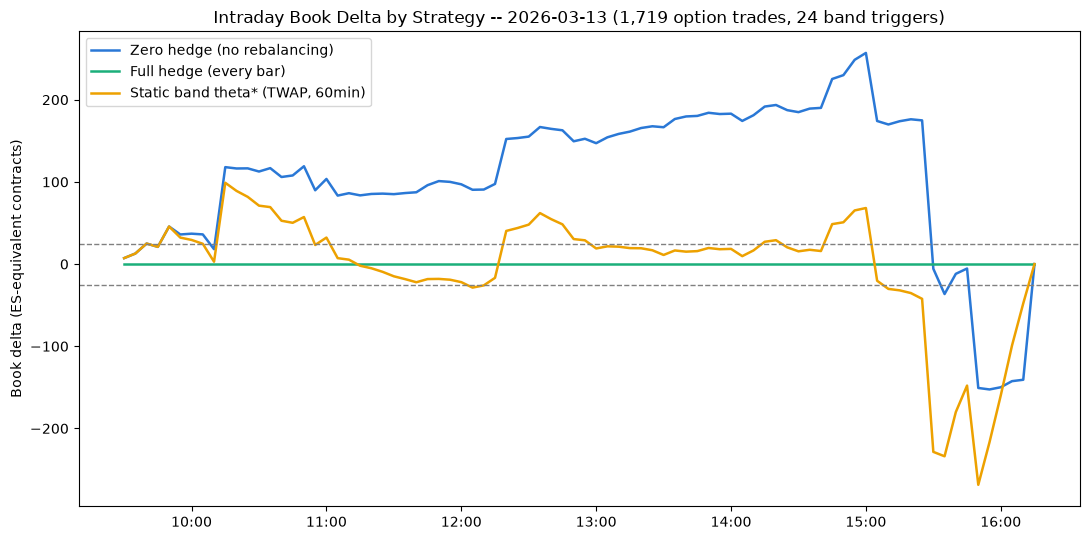

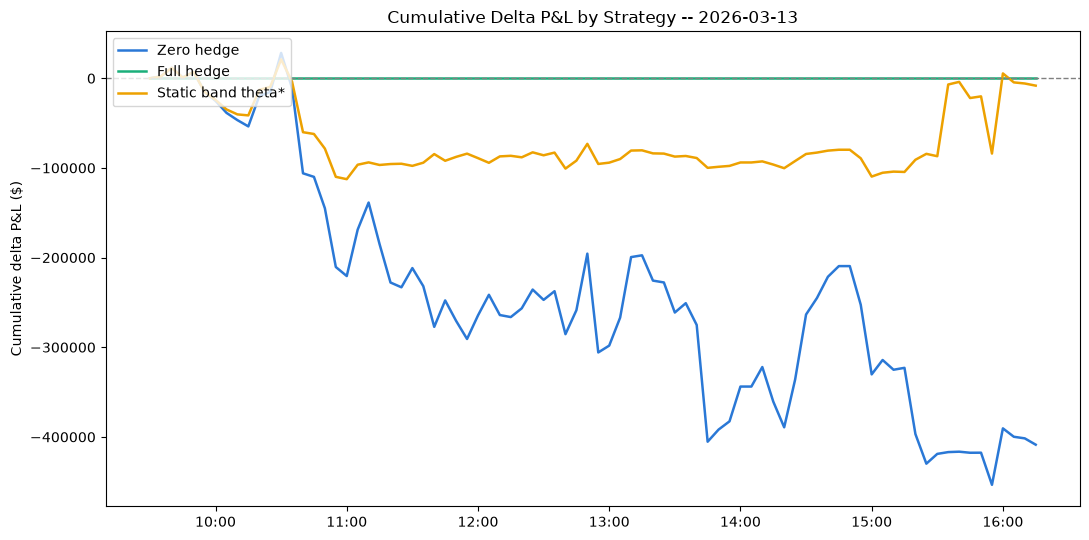

In [15]:
n_trades_per_day = trades.groupby("trade_date").size()
busiest_day = n_trades_per_day.idxmax()
day = day_paths[busiest_day]

zero_path = simulate_day(day, H=None, eps=None, cooldown_min=None, horizon_min=None, method=None, zero_hedge=True, return_path=True)["resid_path"]
full_path = simulate_day(day, H=None, eps=None, cooldown_min=None, horizon_min=None, method=None, full_hedge=True, return_path=True)["resid_path"]
static_result = simulate_day(day, H=theta_star["H"], eps=theta_star["eps"], cooldown_min=theta_star["cooldown_min"], horizon_min=theta_star["horizon_min"], method=theta_star["method"], return_path=True)
static_path = static_result["resid_path"]

bar_time = day["bar_time"]
prices = day["es1_price"]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(bar_time, zero_path, label="Zero hedge (no rebalancing)", linewidth=1.8, color="#2a78d6")
ax.plot(bar_time, full_path, label="Full hedge (every bar)", linewidth=1.8, color="#1baf7a")
ax.plot(bar_time, static_path, label=f"Static band theta* ({theta_star['method'].upper()}, {theta_star['horizon_min']:.0f}min)", linewidth=1.8, color="#eda100")
ax.axhline(theta_star["H"], color="grey", linestyle="--", linewidth=1)
ax.axhline(-theta_star["H"], color="grey", linestyle="--", linewidth=1)
ax.set_title(f"Intraday Book Delta by Strategy -- {busiest_day.date()} ({n_trades_per_day[busiest_day]:,} option trades, {static_result['n_triggers']} band triggers)")
ax.set_ylabel("Book delta (ES-equivalent contracts)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(OUTPUT_FIGURE_DIR / "alex_intraday_delta_path.png", dpi=150)
plt.show()


def delta_pnl(resid: np.ndarray, price: np.ndarray) -> np.ndarray:
    price_diff = np.diff(price, prepend=price[0])
    resid_prev = np.concatenate([[0.0], resid[:-1]])
    return np.cumsum(ES_MULTIPLIER * resid_prev * price_diff)


fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(bar_time, delta_pnl(zero_path, prices), label="Zero hedge", linewidth=1.8, color="#2a78d6")
ax.plot(bar_time, delta_pnl(full_path, prices), label="Full hedge", linewidth=1.8, color="#1baf7a")
ax.plot(bar_time, delta_pnl(static_path, prices), label=f"Static band theta*", linewidth=1.8, color="#eda100")
ax.axhline(0, color="grey", linestyle="--", linewidth=1)
ax.set_title(f"Cumulative Delta P&L by Strategy -- {busiest_day.date()}")
ax.set_ylabel("Cumulative delta P&L ($)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(OUTPUT_FIGURE_DIR / "alex_intraday_delta_pnl.png", dpi=150)
plt.show()

## 12. Final Recommendation

In [16]:
cost_saving_vs_full = (1 - theta_star["cost_norm"]) * 100
risk_saving_vs_zero = (1 - theta_star["risk_norm"]) * 100
cost_vs_zero = (theta_star["execution_cost"] / zero_hedge_agg["exec_cost"] - 1) * 100

print("theta* = " f"(H={theta_star['H']:.0f}, eps={theta_star['eps']:.0%}, T_cooldown={theta_star['cooldown_min']:.0f}min, "
      f"e={theta_star['method'].upper()}, tau={theta_star['horizon_min']:.0f}min)")
print(f"Execution cost: {cost_saving_vs_full:.1f}% lower than Full Hedge; {cost_vs_zero:+.1f}% vs. Zero Hedge.")
print(f"Delta risk (RMS realized residual-delta P&L): {risk_saving_vs_zero:.1f}% lower than Zero Hedge.")
print(f"Standardized loss L_std(theta*) = {theta_star['L_std']:.3f} vs. Zero Hedge {summary_table.loc[0, 'L_std']:.3f} and Full Hedge {summary_table.loc[1, 'L_std']:.3f}.")
print("\nAnswer to the key empirical question: static delta bands with a breach buffer, cooldown, and TWAP/VWAP")
print("execution reduce the standardized cost-risk loss relative to both benchmarks in this backtest.")
print("\nOut of scope here, per the proposal's own Future Extensions (p.15): dynamic/gamma-conditioned bands,")
print("Almgren-Chriss execution, and arrival-aware execution. This notebook implements the static-band baseline only.")

theta* = (H=25, eps=10%, T_cooldown=0min, e=TWAP, tau=60min)
Execution cost: 75.7% lower than Full Hedge; -39.0% vs. Zero Hedge.
Delta risk (RMS realized residual-delta P&L): 65.2% lower than Zero Hedge.
Standardized loss L_std(theta*) = 0.591 vs. Zero Hedge 1.399 and Full Hedge 1.000.

Answer to the key empirical question: static delta bands with a breach buffer, cooldown, and TWAP/VWAP
execution reduce the standardized cost-risk loss relative to both benchmarks in this backtest.

Out of scope here, per the proposal's own Future Extensions (p.15): dynamic/gamma-conditioned bands,
Almgren-Chriss execution, and arrival-aware execution. This notebook implements the static-band baseline only.


### Dollar Comparison vs. Full Hedge

Execution-cost saving of theta* relative to Full Hedge, in dollars, with the delta risk
accepted in exchange. Framing note: this is an execution-cost saving, not free P&L --
Full Hedge buys zero delta risk with that spend, while theta* accepts a residual delta
swing. Dollar levels inherit the cost-model assumptions (alpha, spread proxy); the
percentage comparisons are the robust quantities across the Section 10 sweeps.

In [17]:
n_days = len(day_paths)
cost_saved_total = full_hedge_agg["exec_cost"] - theta_star["execution_cost"]

print(f"Execution cost, Full Hedge:         ${full_hedge_agg['exec_cost']:,.0f} over {n_days} trading days")
print(f"Execution cost, Zero Hedge:         ${zero_hedge_agg['exec_cost']:,.0f}  (entirely the forced EOD flatten)")
print(f"Execution cost, static band theta*: ${theta_star['execution_cost']:,.0f}")
print(f"Saving vs. Full Hedge:              ${cost_saved_total:,.0f} total  (~${cost_saved_total / n_days:,.0f} per trading day)")
print()
print(f"Delta risk accepted in exchange (RMS residual-delta P&L per 5-minute bar):")
print(f"  Full Hedge: $0 by construction | theta*: ${theta_star['delta_risk_rms']:,.0f} | Zero Hedge: ${zero_hedge_agg['risk_rms']:,.0f}")

Execution cost, Full Hedge:         $3,692,884 over 102 trading days
Execution cost, Zero Hedge:         $1,473,208  (entirely the forced EOD flatten)
Execution cost, static band theta*: $898,678
Saving vs. Full Hedge:              $2,794,206 total  (~$27,394 per trading day)

Delta risk accepted in exchange (RMS residual-delta P&L per 5-minute bar):
  Full Hedge: $0 by construction | theta*: $8,620 | Zero Hedge: $24,801
